In [17]:
!nvidia-smi


Sun Oct  4 18:24:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P0             27W /   70W |     739MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [19]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/mini_novic_storage")

DATA_DIR = DRIVE_ROOT / "datasets"
EMBEDDING_DIR = DRIVE_ROOT / "embeddings"
CHECKPOINT_DIR = DRIVE_ROOT / "checkpoints"
RESULT_DIR = DRIVE_ROOT / "results"

for path in [
    DATA_DIR,
    EMBEDDING_DIR,
    CHECKPOINT_DIR,
    RESULT_DIR
]:
    path.mkdir(parents=True, exist_ok=True)

print("Drive root:", DRIVE_ROOT)

Drive root: /content/drive/MyDrive/mini_novic_storage


In [21]:
!git clone https://github.com/AkhilaNisal/mini_novic.git

Cloning into 'mini_novic'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 19 (delta 4), reused 17 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 4.68 KiB | 4.68 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [22]:
%cd /content/mini_novic
!ls

/content/mini_novic
configs  mini_novic  README.md		     requirements.txt  src
data	 notebooks   requirements-cloud.txt  results


In [23]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

print("Project root:", PROJECT_ROOT)
print("\nFiles:")
for item in PROJECT_ROOT.iterdir():
    print("-", item.name)

Project root: /content/mini_novic

Files:
- notebooks
- src
- results
- .gitignore
- requirements-cloud.txt
- .git
- requirements.txt
- mini_novic
- configs
- data
- README.md


In [24]:
!pip install -q open_clip_torch

In [25]:
import torch
import open_clip

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("OpenCLIP imported successfully")

PyTorch: 2.11.0+cu130
CUDA: True
GPU: Tesla T4
OpenCLIP imported successfully


In [26]:
models = open_clip.list_pretrained()

print("Number of pretrained configurations:", len(models))
print("\nFirst 10:")
for x in models[:10]:
    print(x)

Number of pretrained configurations: 196

First 10:
('RN50', 'openai')
('RN50', 'yfcc15m')
('RN50', 'cc12m')
('RN101', 'openai')
('RN101', 'yfcc15m')
('RN50x4', 'openai')
('RN50x16', 'openai')
('RN50x64', 'openai')
('ViT-B-32', 'openai')
('ViT-B-32', 'laion400m_e31')


In [27]:
!git pull

Already up to date.


In [28]:
!pip install -q -r requirements-cloud.txt

In [29]:
!git pull

Already up to date.


# 01 - CLIP Exploration

## Objective

Before implementing NOVIC, this notebook investigates the CLIP model that provides
the shared image-text **embedding** space used by NOVIC.

We will explore:

1. How CLIP preprocesses an image.
2. How CLIP tokenizes text.
3. How the image encoder produces an embedding.
4. How the text encoder produces an embedding.
5. L2 normalization of embeddings.
6. Cosine similarity between image and text embeddings.
7. Zero-shot image classification using candidate labels.
8. The effect of changing the candidate label set.
9. The effect of prompt wording.
10. Image-text similarity matrices.
11. Visualization of the embedding space.
12. The image-text modality gap.

The final goal is to understand why NOVIC needs an object decoder rather than
ordinary CLIP candidate-label classification.

## 1. Imports and reproducibility

In [30]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from PIL import Image
import open_clip

In [31]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2. Load a pretrained CLIP model

For the first experiments we use ViT-B/32.

CLIP contains two main components:

- an image encoder
- a text encoder

Both produce vectors in the same semantic embedding space.

In [32]:
MODEL_NAME = "ViT-B-32"
PRETRAINED = "laion2b_s34b_b79k"

model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME,
    pretrained=PRETRAINED
)

tokenizer = open_clip.get_tokenizer(MODEL_NAME)

model = model.to(device)
model.eval()

print("Model loaded successfully")
print("Model:", MODEL_NAME)
print("Pretrained weights:", PRETRAINED)
print("Model device:", next(model.parameters()).device)

Model loaded successfully
Model: ViT-B-32
Pretrained weights: laion2b_s34b_b79k
Model device: cuda:0


Model device: cuda:0 is especially important. It means the CLIP model is currently running on your GPU, not the CPU.

## 3. Inspect the CLIP architecture

In [33]:
print(model)

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [34]:
print("Image embedding dimension:", model.visual.output_dim)

Image embedding dimension: 512


In [35]:
with torch.no_grad():
    sample_tokens = tokenizer(["a photo of a dog"]).to(device)
    sample_text_embedding = model.encode_text(sample_tokens)

print("Text embedding shape:", sample_text_embedding.shape)

Text embedding shape: torch.Size([1, 512])


## 4. Load a test image

In [36]:
TEST_IMAGE_DIR = (
    Path("/content/drive/MyDrive/mini_novic_storage")
    / "datasets"
    / "clip_test"
)

print(TEST_IMAGE_DIR)

/content/drive/MyDrive/mini_novic_storage/datasets/clip_test


Image type: <class 'PIL.Image.Image'>
Image size: (555, 553)


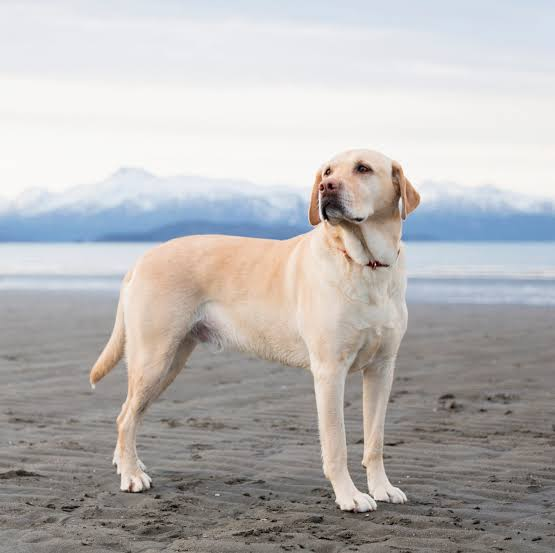

In [37]:
image_path = TEST_IMAGE_DIR / "dog.jpeg"

image = Image.open(image_path).convert("RGB")

print("Image type:", type(image))
print("Image size:", image.size)

display(image)

## 5. CLIP image preprocessing

A normal JPEG image cannot be passed directly into the neural network.

The preprocessing pipeline converts the image into the size and numerical format
expected by CLIP.

In [38]:
print(preprocess)

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeConvertMode()
    MaybeToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


In [39]:
image_tensor = preprocess(image)

print("Tensor shape:", image_tensor.shape)
print("Tensor dtype:", image_tensor.dtype)
print("Minimum value:", image_tensor.min().item())
print("Maximum value:", image_tensor.max().item())

Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Minimum value: -1.7520971298217773
Maximum value: 2.1174569129943848


But neural-network models usually expect a batch of images, even if you're only giving them one image.
PyTorch expects image input in this format:
**[batch, channels, height, width]**

So CLIP wants:
**[B, C, H, W]**

where:

B = number of images

C = channels

H = height

W = width

In [40]:
image_batch = image_tensor.unsqueeze(0)

print(image_batch.shape)

torch.Size([1, 3, 224, 224])


Move it to GPU:

In [41]:
image_batch = image_batch.to(device)

print(image_batch.device)

cuda:0


## 6. Encode the image

The CLIP image encoder converts the image tensor into a semantic embedding vector.

In [42]:
with torch.no_grad():
    image_embedding = model.encode_image(image_batch)

print("Embedding shape:", image_embedding.shape)
print("Embedding dtype:", image_embedding.dtype)
print()
print("First 10 values:")
print(image_embedding[0, :10])

Embedding shape: torch.Size([1, 512])
Embedding dtype: torch.float32

First 10 values:
tensor([-0.0590,  0.3013, -1.0877, -0.3168, -0.0689,  0.7387, -0.2046,  0.2177,
        -0.1435, -0.3529], device='cuda:0')


## 7. L2 normalization

In [43]:
raw_norm = image_embedding.norm(dim=-1)

print("Raw embedding norm:", raw_norm)

Raw embedding norm: tensor([10.1897], device='cuda:0')


The formula is:

$$
\hat{z} = \frac{z}{\|z\|_2}
$$

where

$$
\|z\|_2 =
\sqrt{z_1^2 + z_2^2 + \cdots + z_D^2}
$$

After normalization:

$$
\|\hat{z}\|_2 = 1
$$

This matters a lot later in NOVIC. We will **L2-normalize the cached CLIP embeddings** and verify that their norm is approximately:

$$
1
$$

In [44]:
image_embedding_norm = F.normalize(
    image_embedding,
    dim=-1
)

print(
    "Normalized embedding norm:",
    image_embedding_norm.norm(dim=-1)
)

Normalized embedding norm: tensor([1.], device='cuda:0')


## 8. CLIP text tokenization

Neural networks do not directly process words.

The tokenizer converts text into integer token IDs before the text encoder processes it.

In [45]:
texts = [
    "a photo of a dog",
    "a photo of a cat",
    "a photo of a car",
    "a photo of an airplane",
    "a photo of a chair",
]

tokens = tokenizer(texts)

print("Token tensor shape:", tokens.shape)
print()
print(tokens)

Token tensor shape: torch.Size([5, 77])

tensor([[49406,   320,  1125,   539,   320,  1929, 49407,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0],
        [49406,   320,  1125,   539,   320,  2368, 49407,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,  

77 is the maximum text sequence length chosen by the original CLIP architecture.

This is called the **context length**.

In [46]:
print("First prompt:")
print(texts[0])

print("\nToken IDs:")
print(tokens[0])

First prompt:
a photo of a dog

Token IDs:
tensor([49406,   320,  1125,   539,   320,  1929, 49407,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0])


## 9. Encode text prompts

In [47]:
tokens = tokens.to(device)

with torch.no_grad():
    text_embeddings = model.encode_text(tokens)

print("Text embeddings shape:")
print(text_embeddings.shape)

Text embeddings shape:
torch.Size([5, 512])


Normalize:

In [48]:
text_embeddings_norm = F.normalize(
    text_embeddings,
    dim=-1
)

print(text_embeddings_norm.norm(dim=-1))

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')


## 10. Image-text cosine similarity

CLIP compares image and text embeddings using their orientation in the shared embedding space.
For unit-normalized vectors, the dot product is equal to cosine similarity.

The formula is:

$$
\cos(\theta)
=
\frac{z_I^\top z_T}
{\|z_I\| \|z_T\|}
$$

Since both vectors are normalized:

$$
\cos(\theta)
=
\hat{z}_I^\top \hat{z}_T
$$

In [49]:
similarities = (
    image_embedding_norm
    @ text_embeddings_norm.T
)

print(similarities)

tensor([[0.2995, 0.1581, 0.1590, 0.1387, 0.1481]], device='cuda:0')


In [50]:
similarity_values = similarities[0].cpu().numpy()

results = pd.DataFrame({
    "Prompt": texts,
    "Cosine similarity": similarity_values
})

results = results.sort_values(
    "Cosine similarity",
    ascending=False
)

results

,Prompt,Cosine similarity
0,a photo of a dog,0.299500
2,a photo of a car,0.158951
1,a photo of a cat,0.158060
4,a photo of a chair,0.148139
3,a photo of an airplane,0.138655


### Plot similarities

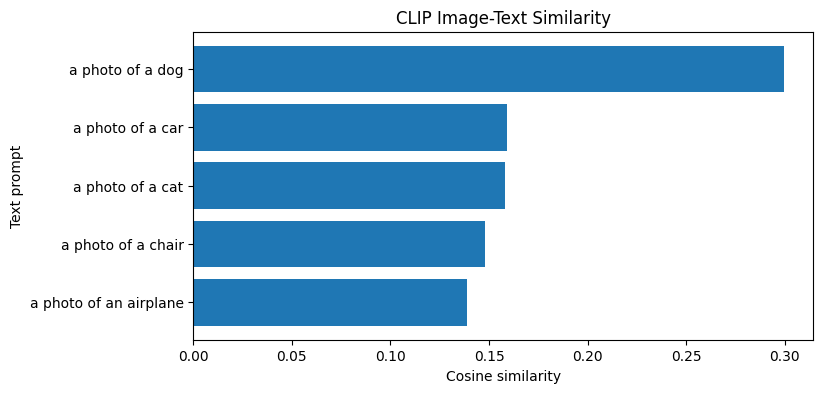

In [51]:
plt.figure(figsize=(8, 4))

plt.barh(
    results["Prompt"],
    results["Cosine similarity"]
)

plt.xlabel("Cosine similarity")
plt.ylabel("Text prompt")
plt.title("CLIP Image-Text Similarity")
plt.gca().invert_yaxis()
plt.show()

## 11. Zero-shot classification

Standard CLIP image classification is performed by comparing an image embedding
with embeddings for a predefined set of candidate class prompts.

In [52]:
class_names = [
    "dog",
    "cat",
    "car",
    "airplane",
    "chair"
]

prompts = [
    f"a photo of a {name}"
    for name in class_names
]

tokens = tokenizer(prompts).to(device)

with torch.no_grad():
    text_features = model.encode_text(tokens)

text_features = F.normalize(
    text_features,
    dim=-1
)

image_features = image_embedding_norm

similarity = image_features @ text_features.T

predicted_index = similarity.argmax(dim=-1).item()

predicted_class = class_names[predicted_index]

print("Predicted class:", predicted_class)

Predicted class: dog


In [53]:
for name, score in zip(
    class_names,
    similarity[0].cpu().tolist()
):
    print(f"{name:10s} {score:.4f}")

dog        0.2995
cat        0.1581
car        0.1590
airplane   0.1392
chair      0.1481


## 12. Candidate-label experiment

Standard CLIP does not generate a class name by itself.

It selects the most similar option from the candidate labels provided to it.

We can demonstrate this limitation by removing the correct class from the candidate set.

In [70]:
candidate_set_1 = [
    "dog",
    "cat",
    "wolf",
    "phone",
    "airplane"
]

In [68]:
def clip_classify(image_features, class_names):
    prompts = [
        f"a photo of a {name}"
        for name in class_names
    ]

    token_ids = tokenizer(prompts).to(device)

    with torch.no_grad():
        text_features = model.encode_text(token_ids)

    text_features = F.normalize(
        text_features,
        dim=-1
    )

    scores = image_features @ text_features.T

    best_idx = scores.argmax(dim=-1).item()

    return (
        class_names[best_idx],
        scores[0].cpu().numpy()
    )

In [71]:
prediction, scores = clip_classify(
    image_embedding_norm,
    candidate_set_1
)

print("Candidate labels:", candidate_set_1)
print("Prediction:", prediction)

Candidate labels: ['dog', 'cat', 'wolf', 'phone', 'airplane']
Prediction: dog


Then remove dog:

In [72]:
candidate_set_2 = [
    "cat",
    "wolf",
    "car",
    "airplane",
    "chair"
]

prediction, scores = clip_classify(
    image_embedding_norm,
    candidate_set_2
)

print("Candidate labels:", candidate_set_2)
print("Prediction:", prediction)

Candidate labels: ['cat', 'wolf', 'car', 'airplane', 'chair']
Prediction: car


## 13. Effect of prompt wording

CLIP text embeddings depend on the exact wording used to describe a class.

In [73]:
dog_prompts = [
    "dog",
    "a dog",
    "a photo of a dog",
    "a photograph of a dog",
    "an image containing a dog",
    "a close-up photo of a dog",
    "a blurry photo of a dog",
]

dog_tokens = tokenizer(dog_prompts).to(device)

with torch.no_grad():
    dog_text_features = model.encode_text(dog_tokens)

dog_text_features = F.normalize(
    dog_text_features,
    dim=-1
)

prompt_scores = (
    image_embedding_norm
    @ dog_text_features.T
)[0].cpu().numpy()

prompt_df = pd.DataFrame({
    "Prompt": dog_prompts,
    "Similarity": prompt_scores
})

prompt_df.sort_values(
    "Similarity",
    ascending=False
)

,Prompt,Similarity
2,a photo of a dog,0.299500
4,an image containing a dog,0.299101
3,a photograph of a dog,0.290422
1,a dog,0.270917
0,dog,0.268670
5,a close-up photo of a dog,0.245452
6,a blurry photo of a dog,0.216297


Plot

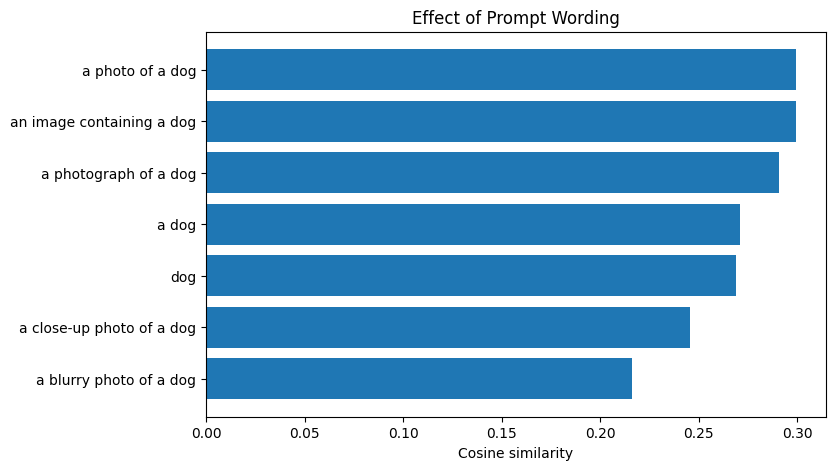

In [74]:
plot_df = prompt_df.sort_values(
    "Similarity",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["Prompt"],
    plot_df["Similarity"]
)

plt.xlabel("Cosine similarity")
plt.title("Effect of Prompt Wording")
plt.show()

## 14. Image-text similarity matrix

In [75]:
image_files = {
    "dog": TEST_IMAGE_DIR / "dog.jpeg",
    "cat": TEST_IMAGE_DIR / "cat.jpeg",
    "car": TEST_IMAGE_DIR / "car.jpg",
    "airplane": TEST_IMAGE_DIR / "airplane.jpg",
}

Images:

In [76]:
image_feature_list = []
image_labels = []

for label, path in image_files.items():

    img = Image.open(path).convert("RGB")

    img_tensor = (
        preprocess(img)
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():
        features = model.encode_image(img_tensor)

    features = F.normalize(
        features,
        dim=-1
    )

    image_feature_list.append(features)
    image_labels.append(label)

image_features_all = torch.cat(
    image_feature_list,
    dim=0
)

print(image_features_all.shape)

torch.Size([4, 512])


Text:

In [77]:
text_labels = [
    "dog",
    "cat",
    "car",
    "airplane"
]

text_prompts = [
    f"a photo of a {label}"
    for label in text_labels
]

text_tokens = tokenizer(text_prompts).to(device)

with torch.no_grad():
    text_features_all = model.encode_text(text_tokens)

text_features_all = F.normalize(
    text_features_all,
    dim=-1
)

In [78]:
similarity_matrix = (
    image_features_all
    @ text_features_all.T
).cpu().numpy()

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=image_labels,
    columns=text_labels
)

similarity_df

,dog,cat,car,airplane
dog,0.299500,0.158060,0.158951,0.139202
cat,0.180449,0.302083,0.177981,0.102843
car,0.110071,0.097567,0.241762,0.128865
airplane,0.100457,0.102046,0.188125,0.314569


## Heatmap without seaborn




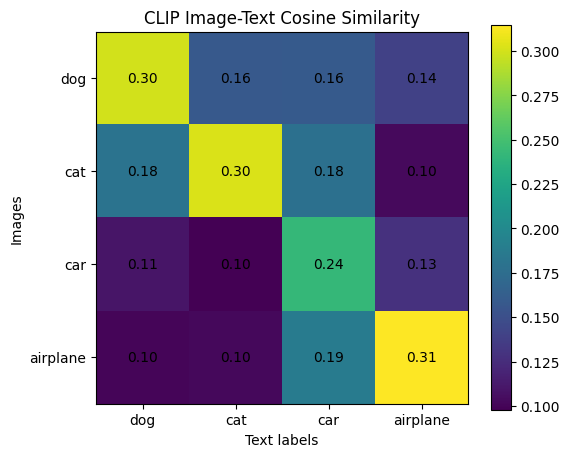

In [79]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(similarity_matrix)

ax.set_xticks(range(len(text_labels)))
ax.set_xticklabels(text_labels)

ax.set_yticks(range(len(image_labels)))
ax.set_yticklabels(image_labels)

ax.set_xlabel("Text labels")
ax.set_ylabel("Images")
ax.set_title("CLIP Image-Text Cosine Similarity")

for i in range(len(image_labels)):
    for j in range(len(text_labels)):
        ax.text(
            j,
            i,
            f"{similarity_matrix[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(im)
plt.show()

## 15. Semantic relationships inside CLIP's text embedding space

In [80]:
concepts = [
    "dog",
    "wolf",
    "cat",
    "tiger",
    "car",
    "bus",
    "truck",
    "airplane",
    "chair",
    "table",
]

concept_prompts = [
    f"a photo of a {concept}"
    for concept in concepts
]

concept_tokens = tokenizer(concept_prompts).to(device)

with torch.no_grad():
    concept_embeddings = model.encode_text(
        concept_tokens
    )

concept_embeddings = F.normalize(
    concept_embeddings,
    dim=-1
)

concept_similarity = (
    concept_embeddings
    @ concept_embeddings.T
).cpu().numpy()

concept_similarity_df = pd.DataFrame(
    concept_similarity,
    index=concepts,
    columns=concepts
)

concept_similarity_df

,dog,wolf,cat,tiger,car,bus,truck,airplane,chair,table
dog,1.000000,0.841882,0.873121,0.785901,0.765696,0.746073,0.763298,0.774010,0.762508,0.727687
wolf,0.841882,1.000000,0.831117,0.821272,0.673646,0.693755,0.705444,0.713376,0.696017,0.670259
cat,0.873121,0.831117,1.000000,0.845627,0.758278,0.732908,0.751698,0.760207,0.767250,0.726799
tiger,0.785901,0.821272,0.845627,1.000000,0.685539,0.709243,0.711716,0.716375,0.709644,0.688224
car,0.765696,0.673646,0.758278,0.685539,1.000000,0.780632,0.861628,0.781239,0.799432,0.766582
bus,0.746073,0.693755,0.732908,0.709243,0.780632,1.000000,0.871652,0.812764,0.755168,0.721035
truck,0.763298,0.705444,0.751698,0.711716,0.861628,0.871652,1.000000,0.810195,0.774700,0.749839
airplane,0.774010,0.713376,0.760207,0.716375,0.781239,0.812764,0.810195,1.000000,0.765498,0.723946
chair,0.762508,0.696017,0.767250,0.709644,0.799432,0.755168,0.774700,0.765498,1.000000,0.837068
table,0.727687,0.670259,0.726799,0.688224,0.766582,0.721035,0.749839,0.723946,0.837068,1.000000


## 16. PCA visualization of text embeddings

Principal Component Analysis (PCA) projects the high-dimensional CLIP embeddings
onto two dimensions for visualization.

This visualization is only an approximation of the original embedding geometry.

In [81]:
from sklearn.decomposition import PCA

embeddings_np = (
    concept_embeddings
    .cpu()
    .numpy()
)

pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(
    embeddings_np
)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

Explained variance ratio: [0.28377187 0.17539491]


Plot:

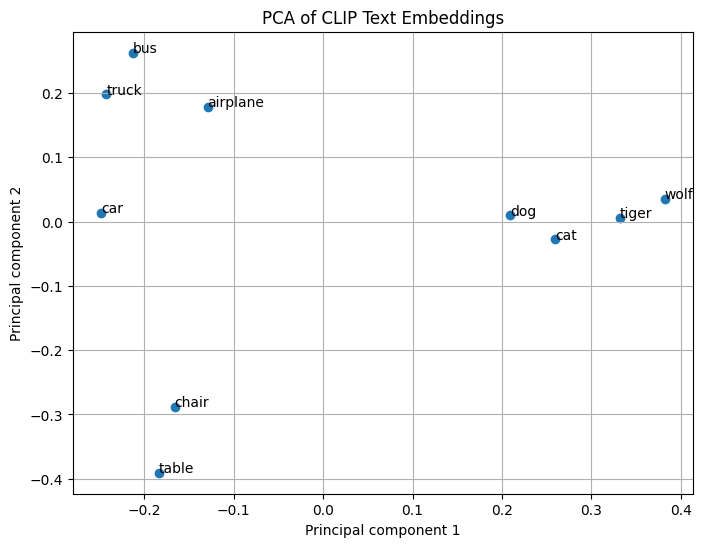

In [82]:
plt.figure(figsize=(8, 6))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1]
)

for i, concept in enumerate(concepts):
    plt.annotate(
        concept,
        (
            embeddings_2d[i, 0],
            embeddings_2d[i, 1]
        )
    )

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("PCA of CLIP Text Embeddings")
plt.grid(True)
plt.show()

## 17. Text-image modality gap

NOVIC trains its object decoder using CLIP text embeddings but applies the decoder
to CLIP image embeddings at inference time.

Therefore, an important question is whether matching image and text embeddings are
identical. They are not.

Here we compare an image embedding with text embeddings describing the same object.

In [83]:
matching_prompts = [
    "dog",
    "a dog",
    "a photo of a dog",
    "a photograph of a dog",
    "an image of a dog"
]

matching_tokens = tokenizer(
    matching_prompts
).to(device)

with torch.no_grad():
    matching_text_embeddings = model.encode_text(
        matching_tokens
    )

matching_text_embeddings = F.normalize(
    matching_text_embeddings,
    dim=-1
)

In [84]:
matching_similarities = (
    image_embedding_norm
    @ matching_text_embeddings.T
)[0]

for prompt, score in zip(
    matching_prompts,
    matching_similarities.cpu().tolist()
):
    print(
        f"{prompt:25s} similarity = {score:.4f}"
    )

dog                       similarity = 0.2687
a dog                     similarity = 0.2709
a photo of a dog          similarity = 0.2995
a photograph of a dog     similarity = 0.2904
an image of a dog         similarity = 0.2771


Now calculate angle:

In [85]:
best_idx = matching_similarities.argmax()

cosine_value = matching_similarities[best_idx]

cosine_value = torch.clamp(
    cosine_value,
    -1.0,
    1.0
)

angle_radians = torch.acos(cosine_value)

angle_degrees = torch.rad2deg(
    angle_radians
)

print(
    "Best matching prompt:",
    matching_prompts[best_idx]
)

print(
    "Cosine similarity:",
    cosine_value.item()
)

print(
    "Angular distance:",
    angle_degrees.item(),
    "degrees"
)

Best matching prompt: a photo of a dog
Cosine similarity: 0.29949963092803955
Angular distance: 72.57244873046875 degrees


This gives a geometrical meaning to the difference.

Even though:
**dog image**

and:
**a photo of a dog**

refer to the same concept, their vectors are not identical.

That is exactly why NOVIC's text → image transfer is nontrivial.

The paper introduces strong embedding perturbations during training specifically because the decoder is trained on text embeddings and later receives image embeddings.

# Visualize image and text embeddings together

In [86]:
combined_embeddings = torch.cat([
    image_features_all,
    text_features_all
], dim=0)

combined_np = (
    combined_embeddings
    .cpu()
    .numpy()
)

pca = PCA(n_components=2)

combined_2d = pca.fit_transform(
    combined_np
)

In [87]:
combined_labels = (
    [f"image:{x}" for x in image_labels]
    +
    [f"text:{x}" for x in text_labels]
)

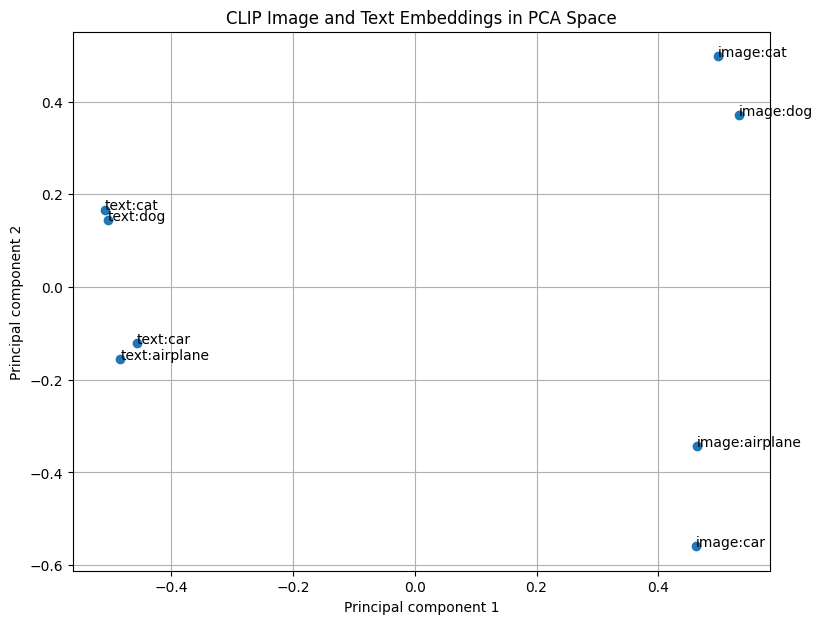

In [88]:
plt.figure(figsize=(9, 7))

plt.scatter(
    combined_2d[:, 0],
    combined_2d[:, 1]
)

for i, label in enumerate(combined_labels):
    plt.annotate(
        label,
        (
            combined_2d[i, 0],
            combined_2d[i, 1]
        )
    )

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title(
    "CLIP Image and Text Embeddings in PCA Space"
)
plt.grid(True)
plt.show()

With just eight samples this isn't scientific evidence of the whole modality gap.

It's an illustration.

# Save useful results to Drive

In [89]:
RESULT_DIR = (
    Path("/content/drive/MyDrive/mini_novic_storage")
    / "results"
    / "clip_exploration"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(RESULT_DIR)

/content/drive/MyDrive/mini_novic_storage/results/clip_exploration


Save tables:

In [90]:
results.to_csv(
    RESULT_DIR / "dog_prompt_similarity.csv",
    index=False
)

similarity_df.to_csv(
    RESULT_DIR / "image_text_similarity_matrix.csv"
)

concept_similarity_df.to_csv(
    RESULT_DIR / "text_concept_similarity.csv"
)

# Conclusions

This notebook experimentally demonstrated the main properties of CLIP that are
required to understand NOVIC.

### 1. CLIP represents images and text as vectors

The image encoder and text encoder map their inputs into a common embedding space.

### 2. Embeddings are high-dimensional semantic representations

A ViT-B/32 CLIP model produces a fixed-dimensional representation for both image
and text inputs.

### 3. L2 normalization enables cosine-similarity comparison

After normalization, the dot product between an image embedding and text embedding
is equivalent to their cosine similarity.

### 4. Standard CLIP zero-shot classification requires candidate labels

CLIP does not directly generate the object name. It compares the image embedding
against embeddings of candidate prompts and chooses the most similar candidate.

Changing the candidate list can therefore change the predicted class.

### 5. Prompt wording affects CLIP classification

Different descriptions of the same object produce different text embeddings and
different image-text similarity scores.

### 6. CLIP aligns image and text semantics but the embeddings are not identical

An image of a dog and the text "a photo of a dog" represent similar concepts,
but their embeddings are not the same.

This difference motivates the text-to-image transfer problem addressed by NOVIC.

### Connection to NOVIC

Standard CLIP:

image → image embedding → compare with candidate text embeddings → choose class

NOVIC:

image → image embedding → autoregressive object decoder → generate object noun

The next stage of this project will use frozen CLIP text embeddings as inputs for
training an object-noun prediction system.